In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'CY'
train_label = 5
train_end_date = '2025-01-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'CY',
 'contract_multiplier': 5,
 'price_tick': 5,
 'margin_rate': 0.05,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'czce',
 'name': '棉纱'}

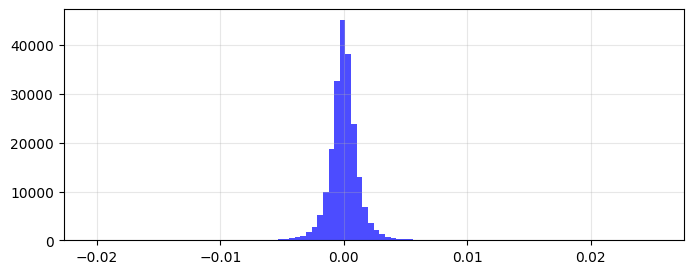

2025-01-01_CY_5


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1885， 筛选之后因子数量：1801

特征重要性过滤： 300 200 	待筛因子个数 1801
无向因子有效个数： 814 有向因子有效个数： 1034
  选择有向特征 237 个，重要性范围: 6040.00 - 87.00
  选择无向特征 158 个，重要性范围: 3356.00 - 137.00

单因子sharpe过滤： 0.5 sp范围-12.3939 ~ 11.0378   待筛因子个数 395

特征相关性性过滤： 300     待筛因子个数 340
  选择特征 300 个, 特征最大相关性0.8987364878779204

已挑选日频开盘因子数量： 5 ['day_first4redcorr', 'day_first4greencorr', 'day_first3power', 'day_first10rev', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_first4greencorr', 'day_first3power', 'day_first10rev', 'day_first10colarrate']

排除指定因子后，剩余特征 299 个


(221, 0, 48, 30)

正在从 /mnt/Data/writable/liaoyuyang/factor/CY/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (280336, 1889)
训练集时间范围: 2021-02-01 09:11:00 至 2024-12-31 14:49:00
[200]	valid_0's rmse: 0.986471
[400]	valid_0's rmse: 0.986071
[600]	valid_0's rmse: 0.986008
[800]	valid_0's rmse: 0.986056
[1000]	valid_0's rmse: 0.986174


<Figure size 1000x600 with 0 Axes>

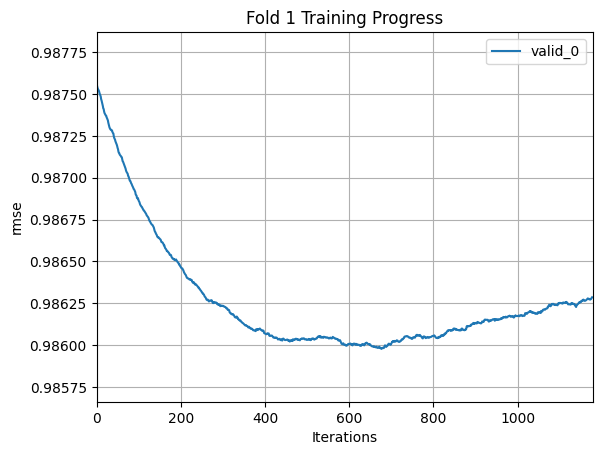

{'train_rmse': np.float64(0.9879624276350604), 'val_rmse': np.float64(0.9984492336989497), 'best_iteration': 678}
test_corr: 0.0299
[200]	valid_0's rmse: 0.931557
[400]	valid_0's rmse: 0.931025
[600]	valid_0's rmse: 0.930867
[800]	valid_0's rmse: 0.930891
[1000]	valid_0's rmse: 0.930968


<Figure size 1000x600 with 0 Axes>

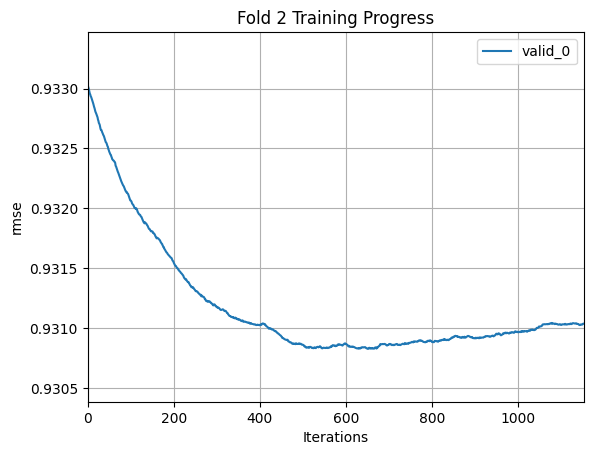

{'train_rmse': np.float64(0.9895638664954169), 'val_rmse': np.float64(0.9975428727424643), 'best_iteration': 652}
test_corr: 0.0269
[200]	valid_0's rmse: 0.861087
[400]	valid_0's rmse: 0.860728
[600]	valid_0's rmse: 0.860571
[800]	valid_0's rmse: 0.860438
[1000]	valid_0's rmse: 0.860359
[1200]	valid_0's rmse: 0.860291
[1400]	valid_0's rmse: 0.860237
[1600]	valid_0's rmse: 0.86015
[1800]	valid_0's rmse: 0.860118
[2000]	valid_0's rmse: 0.860074
[2200]	valid_0's rmse: 0.860022
[2400]	valid_0's rmse: 0.860011
[2600]	valid_0's rmse: 0.860004
[2800]	valid_0's rmse: 0.860015
[3000]	valid_0's rmse: 0.860027
[3200]	valid_0's rmse: 0.86003


<Figure size 1000x600 with 0 Axes>

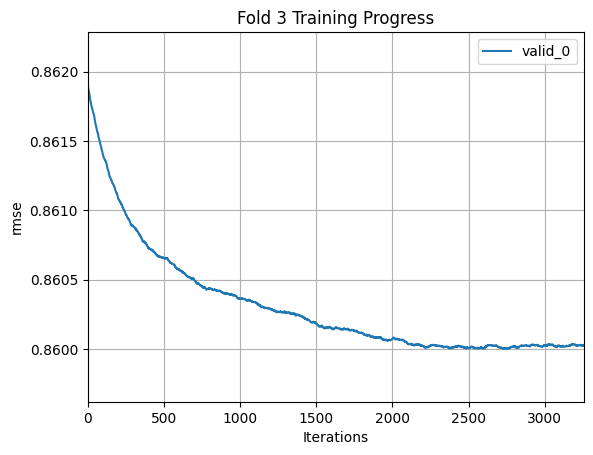

{'train_rmse': np.float64(0.965319553677485), 'val_rmse': np.float64(0.9974068432878276), 'best_iteration': 2756}
test_corr: 0.0260
[200]	valid_0's rmse: 0.769882
[400]	valid_0's rmse: 0.769732
[600]	valid_0's rmse: 0.769582
[800]	valid_0's rmse: 0.769515
[1000]	valid_0's rmse: 0.769478
[1200]	valid_0's rmse: 0.769414
[1400]	valid_0's rmse: 0.769459
[1600]	valid_0's rmse: 0.769463


<Figure size 1000x600 with 0 Axes>

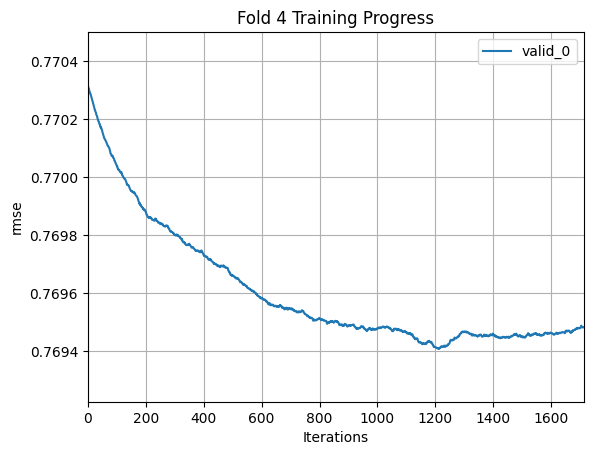

{'train_rmse': np.float64(0.9817987841055132), 'val_rmse': np.float64(0.9986660656591085), 'best_iteration': 1212}
test_corr: 0.0237
[200]	valid_0's rmse: 0.729779
[400]	valid_0's rmse: 0.729545
[600]	valid_0's rmse: 0.729401
[800]	valid_0's rmse: 0.729309
[1000]	valid_0's rmse: 0.729271
[1200]	valid_0's rmse: 0.729255
[1400]	valid_0's rmse: 0.729232
[1600]	valid_0's rmse: 0.729251
[1800]	valid_0's rmse: 0.729265


<Figure size 1000x600 with 0 Axes>

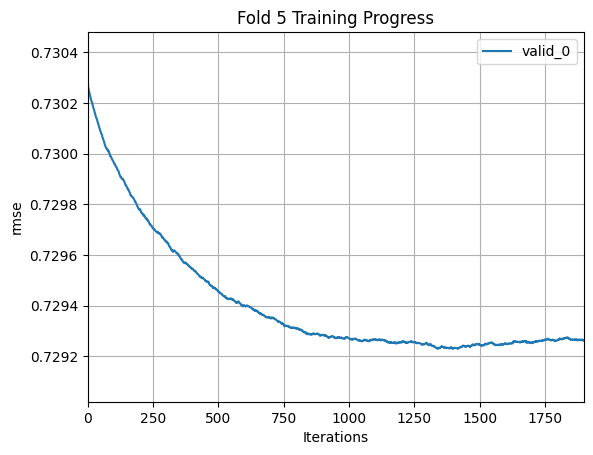

{'train_rmse': np.float64(0.9805470230866231), 'val_rmse': np.float64(0.9982836286676046), 'best_iteration': 1397}
test_corr: 0.0244


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/CY_pred5_2025-01-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-01 09:01:00,CY105,21670.0,21700.0,21670.0,21670.0,21679.183168,21692.741936,12.0,1300975.0,...,29.801980,214,2021-02-01,21686.50,21688.857143,21693.548387,21678.567416,-0.001079,-0.000254,0.000633
1,2021-02-01 09:02:00,CY105,21670.0,21690.0,21670.0,21675.0,21681.834320,21683.370809,5.0,542050.0,...,17.958580,173,2021-02-01,21672.00,21673.928571,21686.842105,21683.310811,0.000465,-0.000753,0.002971
2,2021-02-01 09:03:00,CY105,21675.0,21675.0,21650.0,21670.0,21661.511628,21662.279878,13.0,1408150.0,...,17.744186,225,2021-02-01,21675.00,21669.078947,21660.161290,21659.921466,0.001335,-0.000540,0.002564
3,2021-02-01 09:04:00,CY105,21670.0,21670.0,21670.0,21670.0,21670.000000,21674.669791,0.0,0.0,...,20.285088,228,2021-02-01,21670.00,21670.000000,21670.000000,21670.000000,-0.000598,-0.001101,0.003138
4,2021-02-01 09:05:00,CY105,21670.0,21705.0,21670.0,21690.0,21696.069767,21687.729862,2.0,216900.0,...,20.023256,219,2021-02-01,21670.00,21677.804878,21692.285714,21698.926702,-0.000376,0.000059,0.003866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412163,2026-03-09 14:56:00,CY605,21315.0,21315.0,21305.0,21305.0,21308.352941,21309.615968,36.0,3835775.0,...,7.470588,85,2026-03-09,21313.75,21313.260870,21310.882353,21307.534247,-0.000473,-0.000517,-0.002113
412164,2026-03-09 14:57:00,CY605,21305.0,21315.0,21290.0,21290.0,21301.071429,21301.605732,46.0,4899875.0,...,8.571429,56,2026-03-09,21308.00,21307.000000,21305.000000,21299.565217,-0.000119,-0.000327,-0.001624
412165,2026-03-09 14:58:00,CY605,21290.0,21295.0,21285.0,21285.0,21289.391892,21291.194107,45.0,4790325.0,...,6.891892,74,2026-03-09,21290.25,21288.333333,21290.000000,21289.485294,-0.000041,-0.000670,-0.001245
412166,2026-03-09 14:59:00,CY605,21285.0,21295.0,21285.0,21290.0,21286.891892,21290.142604,29.0,3086850.0,...,7.972973,74,2026-03-09,21287.75,21287.500000,21288.333333,21286.953125,0.000600,-0.000444,-0.001681


In [10]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/89979 [00:00<?, ?it/s]

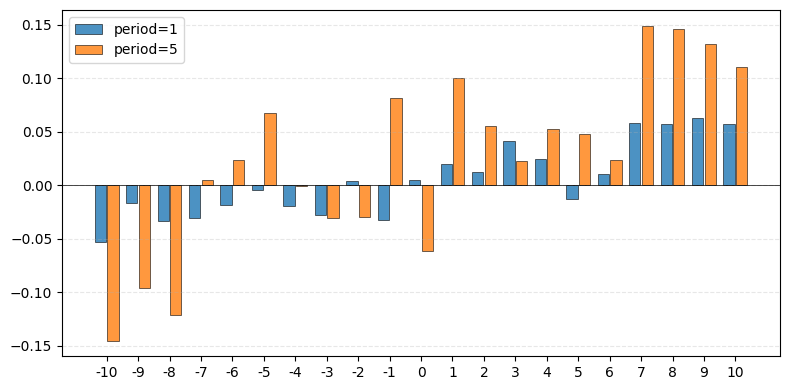

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,19613
空头(-1) 数量,17939
空仓(0) 数量,52429
多头占比,21.80%
空头占比,19.94%
空仓占比,58.27%
交易日数量,266
总收益(非年化%),11.04
总交易次数（开平算一次）,3106
日均交易次数（开平算一次）,11.68


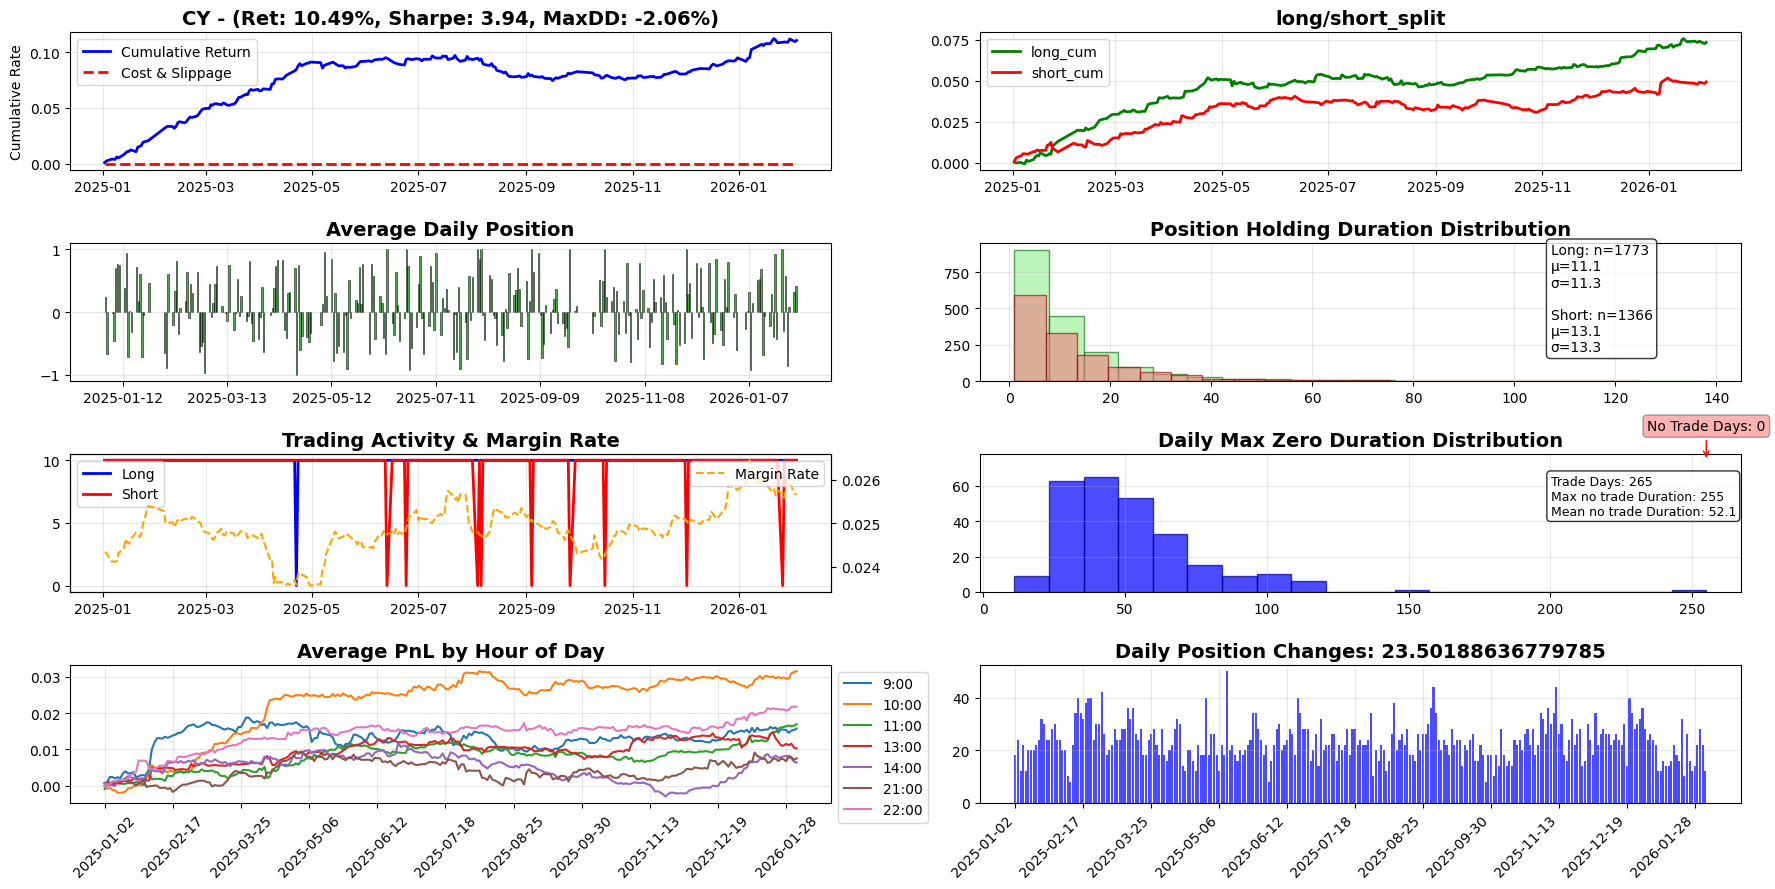

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: CY
📅 总交易日数: 265
📊 总数据点: 96195
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)